# Wild Boar (*Sus scrofa*) Resistance Surface Pipeline — Canton Aargau → Zürich

**Goal:** Build a 25 m permeability/resistance surface for wild boar using GPS telemetry
from Canton Aargau, following Fischer et al. (2024), Clontz et al. (2021), and
Keeley et al. (2016). The calibrated model is then transferred to Canton Zürich.

**Pipeline:**
1. Load & clean telemetry
2. Compute regularised movement metrics
3. Classify steps as *in-patch* or *in-matrix* (hierarchical rule-based classifier)
4. Prepare spatial covariates from SwissTLM3D, DHM25, barriers, and passages
5. Fit integrated Step-Selection Function (iSSF) on *in-matrix* steps
6. Convert iSSF coefficients → resistance surface (Keeley et al. 2016)
7. Transfer resistance surface to Canton Zürich

**Data sources:**
- Telemetry: `WS_Masterfile_final_with_cultures_Aargau.csv`
- SwissTLM3D 2026 (LV95): land cover, water, roads, buildings
- DHM25 (LV03): terrain
- Wildlife barriers: `alg_WTKbarrieren_20221025.gpkg`
- Wildlife passages: `Wildtierpassagen.gdb` → layer `N2023_Version_Wildtierpassagen`
- Cantonal boundary: `swissBOUNDARIES3D`
- Permanent fences (Zürich): `Dauerzäune.shp` (VetAmt Zürich)

## Setup — Packages & Configuration

In [1]:
if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  # Movement ecology
  amt,        # Step-selection functions, track resampling
  # Spatial
  terra,      # Raster / vector operations
  sf,         # Simple Features vector operations
  # Data wrangling
  dplyr,
  tidyr,
  purrr,
  lubridate,
  # Modelling
  survival,   # Conditional logistic regression (clogit)
  broom,      # Tidy model output
  # Visualisation
  ggplot2
)

Loading required package: pacman


In [22]:
# =============================================================================
# CONFIGURATION — adjust paths before running
# =============================================================================

# --- Input paths -------------------------------------------------------------
TELEMETRY_PATH  <- "../data/raw/WS_Masterfile_final_with_cultures_Aargau.csv"
TLM_PATH        <- "../data/raw/SWISSTLM3D_2026_LV95_LN02.gpkg"
DEM_PATH        <- "../data/raw/dhm25_grid_raster.asc"
BOUNDARIES_PATH <- "../data/raw/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
PASSAGES_GDB    <- "../data/raw/Wildtierpassagen.gdb"
PASSAGES_LAYER  <- "N2023_Version_Wildtierpassagen"
FENCE_PATH      <- "../data/raw/Daten_Bericht_VetAmt/Daten_Bericht_VetAmt/Daten/shapefiles/Dauerzäune/Dauerzäune.shp"

# --- Output paths ------------------------------------------------------------
OUT_DIR  <- "../data/processed/"
TEMP_DIR <- "../data/temp/"
dir.create(OUT_DIR,  recursive = TRUE, showWarnings = FALSE)
dir.create(TEMP_DIR, recursive = TRUE, showWarnings = FALSE)

# --- Spatial settings --------------------------------------------------------
TARGET_CRS   <- "EPSG:2056"   # Swiss LV95
DEM_CRS      <- "EPSG:21781"  # LV03 — native CRS of DHM25
TARGET_RES_M <- 25            # Raster resolution in metres

# --- iSSF settings -----------------------------------------------------------
N_RANDOM_STEPS <- 10   # Random control steps per observed step
KEELEY_C       <- 4    # Exponential transformation constant (Fischer 2024)

# --- Telemetry settings ------------------------------------------------------
FIX_RATE_MIN <- 15   # Nominal GPS fix interval (minutes)
FIX_TOL_MIN  <- 5    # Tolerance around fix interval (minutes)
MIN_DAYS     <- 30   # Minimum tracking duration per individual

# --- Shared classification constants -----------------------------------------
FOREST_CLASSES  <- c("Wald", "Wald offen", "Gebueschwald", "Gehoelzflaeche")
WATER_CLASSES   <- c("Fliessgewaesser", "Stehende Gewaesser")
HIGHWAY_CLASSES <- c("Autobahn", "Autostrasse", "Ausfahrt", "Einfahrt")
MAINROAD_CLASSES <- c("10m Strasse", "8m Strasse", "6m Strasse")
EXCLUDE_AREALS  <- c("Wald nicht bestockt", "Abbauareal", "Obstanlage",
                     "Friedhof", "Reben", "Gewässerareal")
FORAGING_CROPS  <- c("Mais", "Weizen", "Erbsen", "Kartoffeln", "Rueben",
                     "Raps", "Gerste", "Sonnenblumen", "Triticale", "Hafer")

cat("Configuration loaded.\n")

Configuration loaded.


## Step 1 — Load & Clean Telemetry

Load the raw CSV, parse timestamps, remove a 5-day capture-shock buffer,
and retain only individuals with at least `MIN_DAYS` of tracking data
and ≥ 100 GPS fixes.

In [3]:
cat("── 1. Loading telemetry ──\n")

raw <- read.csv(TELEMETRY_PATH, sep = ";", stringsAsFactors = FALSE,
                fileEncoding = "UTF-8")

tel <- raw %>%
  mutate(
    datetime_utc = dmy_hms(paste(DatumUTC, ZeitUTC), tz = "UTC"),
    id           = Tier,
    speed_m      = as.numeric(distance)
  ) %>%
  filter(
    !is.na(datetime_utc),
    !is.na(X), !is.na(Y),
    X > 400000, X < 900000,
    Y > 50000,  Y < 350000
  ) %>%
  arrange(id, datetime_utc) %>%
  # Remove first 5 days per individual (capture-shock artefacts)
  group_by(id) %>%
  filter(datetime_utc >= (min(datetime_utc) + days(5))) %>%
  mutate(
    n_days  = as.numeric(difftime(max(datetime_utc), min(datetime_utc),
                                  units = "days")),
    n_fixes = n()
  ) %>%
  ungroup() %>%
  filter(n_days >= MIN_DAYS, n_fixes >= 100)

data.frame(
  Metric = c("Individuals retained", "Total GPS fixes"),
  Value  = c(n_distinct(tel$id), nrow(tel))
)

── 1. Loading telemetry ──


                Metric  Value
1 Individuals retained     14
2      Total GPS fixes 161275

## Step 2 — Compute Regularised Movement Metrics

Resample each track to the 15-minute fix interval, compute step lengths
(`sl_`) and turning angles (`ta_`) via `amt::steps_by_burst()`, then
re-attach the classification covariates (crop type, forest distance,
diel period) needed in Step 3.

In [4]:
cat("── 2. Computing movement metrics ──\n")

# Build amt track in LV95
trk <- tel %>%
  make_track(X, Y, datetime_utc, id = id, crs = TARGET_CRS)

# Resample to nominal fix rate per individual
trk_resampled <- trk %>%
  nest(data = -id) %>%
  mutate(data = map(data, function(d) {
    tryCatch(
      track_resample(d,
                     rate      = minutes(FIX_RATE_MIN),
                     tolerance = minutes(FIX_TOL_MIN)),
      error = function(e) NULL
    )
  })) %>%
  filter(!map_lgl(data, is.null)) %>%
  unnest(data)

# Compute steps (sl_ in metres, ta_ in radians)
steps_raw <- trk_resampled %>%
  nest(data = -id) %>%
  mutate(steps = map(data, steps_by_burst)) %>%
  select(id, steps) %>%
  unnest(steps)

# Re-attach covariates from the original telemetry (joined on animal + timestamp)
steps_all <- steps_raw %>%
  left_join(
    tel %>% select(id, datetime_utc, speed_m, Frucht, Walddist, day),
    by = c("id" = "id", "t1_" = "datetime_utc")
  ) %>%
  mutate(
    hour       = as.integer(format(t1_, "%H")),
    valid_step = sl_ > 0 & !is.na(sl_)
  )

# Step-length distribution
data.frame(
  Percentile    = c("Q25", "Q50", "Q75", "Q90"),
  Step_Length_m = round(quantile(steps_all$sl_, c(.25, .5, .75, .9),
                                 na.rm = TRUE), 1)
)

── 2. Computing movement metrics ──


    Percentile Step_Length_m
25%        Q25           5.8
50%        Q50          13.6
75%        Q75          41.2
90%        Q90         127.3

## Step 3 — Classify Steps as *In-Patch* vs *In-Matrix*

Wild boar alternate between two movement modes. Only **in-matrix steps**
(directed transit between patches) are used to fit the iSSF and generate
the resistance surface.

| Mode | Biology | GPS signal |
|---|---|---|
| **In-patch** | Resting, wallowing, foraging within a patch | Short steps, high turning angles |
| **In-matrix** | Directed transit between patches | Long steps, low turning angles |

### Classification rules

| # | Condition | Label | Source |
|---|---|---|---|
| 1 | `speed_m == 0` or invalid step | in-patch | Logical |
| 2 | `sl_ ≥ 250 m` | in-matrix | Podgórski et al. 2013 |
| 3 | `sl_ ≥ 150 m` AND `|ta_| < π/4` | in-matrix | Clontz et al. 2021 |
| 4 | Day + forest (`Walddist == 0`) + `sl_ < 50 m` | in-patch | Fischer & Ranzoni 2017 |
| 5 | Night + foraging crop + `sl_ < 150 m` | in-patch | Schley & Roper 2003 |
| 6 | Night + `Walddist > 50 m` + `sl_ ≥ 50 m` | in-matrix | Thurfjell et al. 2009 |
| 7 | Default (conservative) | in-patch | Blasetti et al. 1988 |

In [5]:
cat("── 3. Classifying steps ──\n")

steps_classified <- steps_all %>%
  mutate(
    state_label = case_when(

      # 1. Stationary fix — definitively in-patch
      !valid_step | speed_m == 0
        ~ "in-patch",

      # 2. High-speed long-distance transit (Podgórski et al. 2013)
      sl_ >= 250
        ~ "in-matrix",

      # 3. Directed medium-distance movement (Clontz et al. 2021)
      sl_ >= 150 & !is.na(ta_) & abs(ta_) < (pi / 4)
        ~ "in-matrix",

      # 4. Daytime resting in forest (Fischer & Ranzoni 2017)
      tolower(day) == "day" & !is.na(Walddist) & Walddist == 0 & sl_ < 50
        ~ "in-patch",

      # 5. Nocturnal field foraging (Schley & Roper 2003)
      tolower(day) == "night" &
        !is.na(Frucht) & Frucht %in% FORAGING_CROPS & sl_ < 150
        ~ "in-patch",

      # 6. Nocturnal open-area transit (Thurfjell et al. 2009)
      tolower(day) == "night" &
        !is.na(Walddist) & Walddist > 50 &
        (is.na(Frucht) | !Frucht %in% FORAGING_CROPS) & sl_ >= 50
        ~ "in-matrix",

      # 7. Conservative default — wild boar spend ~70–80% of time in patches
      TRUE ~ "in-patch"
    )
  )

in_patch  <- steps_classified %>% filter(state_label == "in-patch")
in_matrix <- steps_classified %>% filter(state_label == "in-matrix")

write.csv(in_patch,  file.path(OUT_DIR, "WildBoar_InPatch_Steps.csv"),  row.names = FALSE)
write.csv(in_matrix, file.path(OUT_DIR, "WildBoar_InMatrix_Steps.csv"), row.names = FALSE)

tbl <- table(steps_classified$state_label)
data.frame(
  State    = names(tbl),
  Count    = as.integer(tbl),
  Percent  = round(100 * as.integer(tbl) / sum(tbl), 1)
)

── 3. Classifying steps ──


      State  Count Percent
1 in-matrix   8977     6.7
2  in-patch 124138    93.3

## Step 4 — Prepare Spatial Covariates (Aargau)

Build a 25 m raster stack covering Canton Aargau (+ 2 km processing buffer):

| Layer | Source | Wild boar relevance |
|---|---|---|
| Forest binary | SwissTLM3D `tlm_bb_bodenbedeckung` | Resting cover, core patch |
| Forest density (50 m) | Focal mean | Stepping-stone quality |
| Distance to forest edge | `terra::distance()` | Edge-foraging behaviour |
| Slope / TRI | DHM25 | Energy cost / habitat heterogeneity |
| Distance to water | SwissTLM3D water classes | Thermoregulation, wallowing |
| Distance to infrastructure | Roads, buildings, railways | Avoidance / barrier |
| Highway binary | Autobahn, Autostrasse | Absolute barrier |
| Wildlife passages | `Wildtierpassagen.gdb` | Connectivity enhancement |

In [30]:
cat("── 4a. Study area boundary ──\n")

kantone <- st_read(BOUNDARIES_PATH, layer = "tlm_kantonsgebiet", quiet = TRUE) %>%
  st_transform(2056)

aargau_poly   <- kantone %>% filter(name == "Aargau")
aargau_vect   <- vect(aargau_poly)

# 1. Get the exact bounding box (rectangle) of Canton Aargau
bbox <- st_bbox(aargau_poly)

# 2. Expand the rectangle mathematically by 2000 meters in all directions
bbox["xmin"] <- bbox["xmin"] - 2000
bbox["ymin"] <- bbox["ymin"] - 2000
bbox["xmax"] <- bbox["xmax"] + 2000
bbox["ymax"] <- bbox["ymax"] + 2000

# 3. Convert the expanded box back into a polygon for spatial filtering (WKT)
aargau_bbox_buffered <- st_as_sfc(bbox)
aargau_wkt <- st_as_text(aargau_bbox_buffered)

# 4. Create the master grid based on this perfectly expanded rectangle
master_grid <- rast(ext(vect(aargau_bbox_buffered)), resolution = TARGET_RES_M, crs = "EPSG:2056")

cat(sprintf("  Master grid: %d rows × %d cols, res = %d m\n",
            nrow(master_grid), ncol(master_grid), TARGET_RES_M))

── 4a. Study area boundary ──
  Master grid: 2304 rows × 2405 cols, res = 25 m


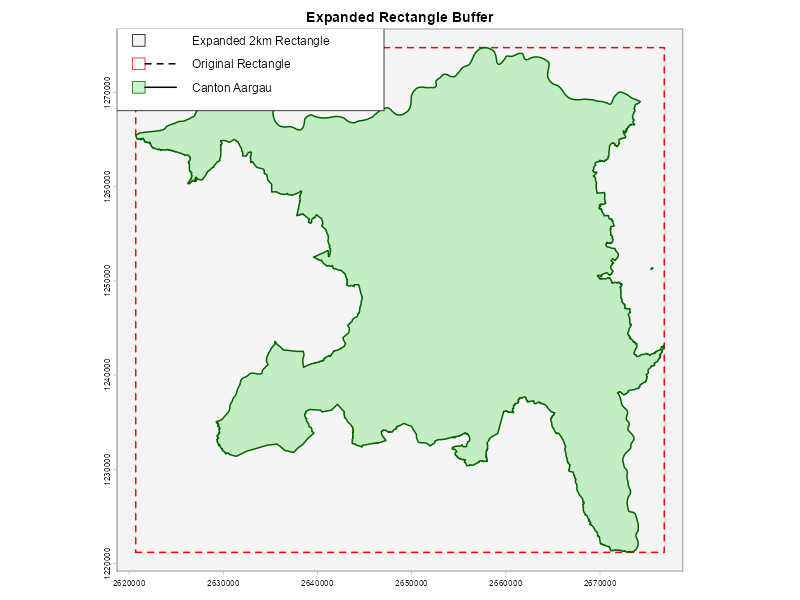

In [31]:
# Fill grid temporarily for rendering
master_grid[] <- 1

# Plot the new master grid (the expanded rectangle)
plot(master_grid, col = "whitesmoke", main = "Expanded Rectangle Buffer", legend = FALSE)

# Plot the original bounding box (before the 2km expansion)
plot(st_as_sfc(st_bbox(aargau_poly)), add = TRUE, border = "red", lty = 2, lwd = 2)

# Plot the actual Canton geometry inside
plot(aargau_vect, add = TRUE, border = "darkgreen", col = rgb(0, 0.8, 0, 0.2), lwd = 2)

legend("topleft", 
       legend = c("Expanded 2km Rectangle", "Original Rectangle", "Canton Aargau"),
       fill = c("whitesmoke", NA, rgb(0, 0.8, 0, 0.2)),
       border = c("black", "red", "darkgreen"),
       lty = c(NA, 2, 1), lwd = c(NA, 2, 2), bg = "white")

# Reset grid to NA!
master_grid[] <- NA

In [32]:
cat("── 4b. Forest cover, density & edge distance ──\n")

# Helper: rasterize a vector layer with touches = TRUE (critical for narrow features)
stamp <- function(r, sf_obj, val = 1) {
  if (!is.null(sf_obj) && nrow(sf_obj) > 0)
    rasterize(vect(sf_obj), r, field = val, update = TRUE, touches = TRUE)
  else r
}

# Load land cover once — reused for forest and water
bodenbedeckung <- st_read(TLM_PATH, layer = "tlm_bb_bodenbedeckung",
                           wkt_filter = aargau_wkt, quiet = TRUE)

# --- Forest binary ---
forest_sf <- bodenbedeckung %>% filter(objektart %in% FOREST_CLASSES)
r_forest  <- rasterize(vect(forest_sf), master_grid,
                       field = 1, background = 0, touches = TRUE)
r_forest  <- mask(r_forest, aargau_vect)
names(r_forest) <- "forest"

# --- Forest density: proportion of forest in a 50 m radius ---
cat("  Calculating 50 m forest density...\n")
r_forest_dens <- focal(r_forest, w = focalMat(r_forest, 50, "circle"),
                       fun = "mean", na.rm = TRUE)
r_forest_dens <- mask(r_forest_dens, aargau_vect)
names(r_forest_dens) <- "forest_density"

# --- Distance to nearest forest pixel ---
# Background MUST be NA (not 0) for terra::distance() to work correctly
cat("  Calculating distance to forest edge...\n")
r_dist_forest <- distance(ifel(r_forest == 1, 1, NA))
r_dist_forest <- mask(r_dist_forest, aargau_vect)
names(r_dist_forest) <- "dist_forest_edge"

writeRaster(r_forest,      file.path(TEMP_DIR, "forest.tif"),           overwrite = TRUE)
writeRaster(r_forest_dens, file.path(TEMP_DIR, "forest_density.tif"),   overwrite = TRUE)
writeRaster(r_dist_forest, file.path(TEMP_DIR, "dist_forest_edge.tif"), overwrite = TRUE)
cat("  Forest layers saved.\n")

── 4b. Forest cover, density & edge distance ──


Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length


  Calculating 50 m forest density...
  Calculating distance to forest edge...
  Forest layers saved.


In [33]:
cat("── 4c. Terrain: slope and TRI from DHM25 ──\n")

# DHM25 has no embedded CRS — assign LV03 manually before reprojecting
dem_raw      <- rast(DEM_PATH)
crs(dem_raw) <- DEM_CRS

# Crop in native projection first (faster), then reproject to LV95 master grid
dem_cropped <- crop(dem_raw, ext(st_transform(aargau_buffer, 21781)))
dem_lv95    <- project(dem_cropped, master_grid, method = "bilinear")

r_slope <- terrain(dem_lv95, v = "slope", unit = "degrees")
r_slope <- mask(r_slope, aargau_vect)
names(r_slope) <- "slope"

# TRI (Riley et al. 1999): captures habitat heterogeneity beyond slope alone
r_tri <- terrain(dem_lv95, v = "TRI")
r_tri <- mask(r_tri, aargau_vect)
names(r_tri) <- "tri"

writeRaster(r_slope, file.path(TEMP_DIR, "slope.tif"), overwrite = TRUE)
writeRaster(r_tri,   file.path(TEMP_DIR, "tri.tif"),   overwrite = TRUE)
cat("  Terrain layers saved.\n")

── 4c. Terrain: slope and TRI from DHM25 ──
  Terrain layers saved.


In [34]:
# -----------------------------------------------------------------------------
cat("── 4d. Distance to water ──\n")

stehendes_gewaesser <- st_read(TLM_PATH, layer = "tlm_gewaesser_stehendes_gewaesser",
                               wkt_filter = aargau_wkt, quiet = TRUE)

fliessgewaesser <- st_read(TLM_PATH, layer = "tlm_gewaesser_fliessgewaesser",
                           wkt_filter = aargau_wkt, quiet = TRUE)

# 1. Prepare the blank master grid
r_water_bin <- rast(master_grid)
r_water_bin[] <- NA

# 2. Rasterize Standing Water (Lakes/Ponds)
# st_make_valid() quietly fixes any broken topological glitches in the TLM3D data
if (nrow(stehendes_gewaesser) > 0) {
  valid_stehend <- st_make_valid(stehendes_gewaesser)
  r_water_bin <- rasterize(vect(valid_stehend), r_water_bin,
                           field = 1, update = TRUE, touches = TRUE)
}

# 3. Rasterize Flowing Water (Rivers/Streams)
if (nrow(fliessgewaesser) > 0) {
  valid_fliess <- st_make_valid(fliessgewaesser)
  r_water_bin <- rasterize(vect(valid_fliess), r_water_bin,
                           field = 1, update = TRUE, touches = TRUE)
}

# 4. Calculate Euclidean distance to the nearest water pixel
cat("  Calculating distance matrix...\n")
r_dist_water <- distance(r_water_bin)

# 5. Mask strictly to the Canton Aargau study area
r_dist_water <- mask(r_dist_water, aargau_vect)
names(r_dist_water) <- "dist_water"

# 6. Save to the temporary directory
writeRaster(r_dist_water, file.path(TEMP_DIR, "dist_water.tif"), overwrite = TRUE)
cat("  Water distance layer saved.\n")

── 4d. Distance to water ──
  Calculating distance matrix...
  Water distance layer saved.


In [35]:
cat("── 4e. Infrastructure, highways & wildlife passages ──\n")

# --- Load vector layers ------------------------------------------------------
strassen  <- st_read(TLM_PATH, layer = "tlm_strassen_strasse",
                     wkt_filter = aargau_wkt, quiet = TRUE)
gebaeude  <- st_read(TLM_PATH, layer = "tlm_bauten_gebaeude_footprint",
                     wkt_filter = aargau_wkt, quiet = TRUE)
eisenbahn <- tryCatch(
  st_read(TLM_PATH, layer = "tlm_oev_eisenbahn",
          wkt_filter = aargau_wkt, quiet = TRUE), error = function(e) NULL)
areal     <- tryCatch(
  st_read(TLM_PATH, layer = "tlm_areale_nutzungsareal",
          wkt_filter = aargau_wkt, quiet = TRUE), error = function(e) NULL)

autobahn <- strassen %>% filter(objektart %in% HIGHWAY_CLASSES)
hauptstr <- strassen %>% filter(objektart %in% MAINROAD_CLASSES)
siedlung <- if (!is.null(areal)) areal %>% filter(!objektart %in% EXCLUDE_AREALS) else NULL

# --- Infrastructure distance raster ------------------------------------------
r_infra <- rast(master_grid); r_infra[] <- NA
r_infra <- stamp(r_infra, gebaeude)
r_infra <- stamp(r_infra, autobahn)
r_infra <- stamp(r_infra, hauptstr)
r_infra <- stamp(r_infra, eisenbahn)
r_infra <- stamp(r_infra, siedlung)

r_dist_infra <- distance(r_infra)
r_dist_infra <- mask(r_dist_infra, aargau_vect)
names(r_dist_infra) <- "dist_infra"

# --- Highway binary (absolute barrier in Step 6) -----------------------------
r_highway <- rast(master_grid); r_highway[] <- 0
r_highway  <- stamp(r_highway, autobahn)
r_highway  <- mask(r_highway, aargau_vect)
names(r_highway) <- "highway"

# --- Wildlife passages (burned in as R_min in Step 6) ------------------------
passages_sf <- tryCatch(
  st_read(PASSAGES_GDB, layer = PASSAGES_LAYER, quiet = TRUE) %>%
    st_transform(2056) %>%
    st_filter(aargau_buffer),
  error = function(e) { message("  Note: passages layer not loaded."); NULL }
)

r_passages <- rast(master_grid); r_passages[] <- 0
if (!is.null(passages_sf) && nrow(passages_sf) > 0) {
  r_passages <- stamp(r_passages, st_buffer(passages_sf, dist = 30))
}
names(r_passages) <- "passages"

writeRaster(r_dist_infra, file.path(TEMP_DIR, "dist_infra.tif"), overwrite = TRUE)
writeRaster(r_highway,    file.path(TEMP_DIR, "highway.tif"),    overwrite = TRUE)
writeRaster(r_passages,   file.path(TEMP_DIR, "passages.tif"),   overwrite = TRUE)
cat("  Infrastructure and passage layers saved.\n")

── 4e. Infrastructure, highways & wildlife passages ──


Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length


  Infrastructure and passage layers saved.


In [36]:
cat("── 4f. Assemble covariate stack ──\n")

cov_stack <- c(r_forest, r_forest_dens, r_dist_forest,
               r_slope, r_tri, r_dist_water, r_dist_infra)
names(cov_stack) <- c("forest", "forest_density", "dist_forest_edge",
                      "slope", "tri", "dist_water", "dist_infra")

writeRaster(cov_stack, file.path(TEMP_DIR, "covariate_stack.tif"), overwrite = TRUE)

cat(sprintf("  Stack: %d layers @ %d m resolution\n",
            nlyr(cov_stack), TARGET_RES_M))
print(names(cov_stack))

── 4f. Assemble covariate stack ──
  Stack: 7 layers @ 25 m resolution
[1] "forest"           "forest_density"   "dist_forest_edge" "slope"           
[5] "tri"              "dist_water"       "dist_infra"      


## Step 5 — Integrated Step-Selection Function (iSSF)

Fit a conditional logistic regression on **in-matrix steps only**, comparing
each observed step to 10 random alternatives drawn from the empirical
step-length and turning-angle distributions.

Covariates are z-standardised so β coefficients are directly comparable.
- **Positive β** → habitat preferred during transit → lower resistance
- **Negative β** → habitat avoided during transit → higher resistance

The scaling parameters (mean, SD per covariate) are saved — they are used
again in Steps 6 and 7 to ensure Zürich rasters are scaled identically
to the Aargau training data.

In [37]:
cat("── 5. Fitting iSSF on in-matrix steps ──\n")

# --- 1. Prepare clean in-matrix steps ----------------------------------------
in_matrix_clean <- in_matrix %>%
  filter(!is.na(sl_), !is.na(ta_), sl_ > 0)

class(in_matrix_clean) <- c("steps_xyt", "steps_xy", "data.frame")
cat(sprintf("  In-matrix steps: %d\n", nrow(in_matrix_clean)))

# --- 2. Generate random control steps ----------------------------------------
issf_data <- in_matrix_clean %>%
  random_steps(n_control = N_RANDOM_STEPS) %>%
  mutate(
    log_sl = log(sl_ + 1),   # Movement kernel term
    cos_ta = cos(ta_)        # Directional persistence term
  )

# --- 3. Extract covariate values at step endpoints ---------------------------
cat("  Extracting covariates at step endpoints...\n")

# 1. Check your raw coordinates to determine their native format
is_lv03 <- mean(issf_data$x2_, na.rm = TRUE) < 1000000

# 2. Assign the CORRECT native CRS based on the coordinate numbers
native_crs <- ifelse(is_lv03, "EPSG:21781", "EPSG:2056")
cat(sprintf("  Detected native point CRS as: %s\n", native_crs))

# 3. Create the spatial points object with the native CRS
pts <- terra::vect(issf_data, geom = c("x2_", "y2_"), crs = native_crs)

# 4. CRITICAL FIX: Mathematically project the points to exactly match the raster
pts_projected <- terra::project(pts, terra::crs(cov_stack))

# 5. Extract the values using the newly aligned points
ext_val <- terra::extract(cov_stack, pts_projected)

# 6. Bind to the dataframe and drop NoData rows (steps outside Canton Aargau)
issf_data <- cbind(issf_data, ext_val[, -1])
issf_data <- issf_data %>%
  filter(complete.cases(across(all_of(names(cov_stack)))))

cat(sprintf("  Valid steps after extraction: %d\n", nrow(issf_data)))
if (nrow(issf_data) == 0) stop("No valid steps. The extents still do not overlap.")

# --- 4. Identify and z-standardise valid covariates --------------------------
# Continuous covariates (exclude binary forest — handled as factor)
continuous_covs <- c("forest_density", "dist_forest_edge",
                     "slope", "tri", "dist_water", "dist_infra")
available_covs  <- intersect(continuous_covs, names(issf_data))

# Drop covariates with zero variance (constant raster or no data)
valid_covs <- Filter(function(cov) {
  s <- sd(issf_data[[cov]], na.rm = TRUE)
  if (is.na(s) || s == 0) {
    cat(sprintf("  WARNING: '%s' dropped (zero variance)\n", cov))
    FALSE
  } else TRUE
}, available_covs)

# Save scaling parameters — MUST be reused for prediction rasters in Steps 6 & 7
scale_params <- issf_data %>%
  summarise(across(all_of(valid_covs),
                   list(mean = ~ mean(.x, na.rm = TRUE),
                        sd   = ~ sd(.x,   na.rm = TRUE))))

# Z-standardise
issf_data <- issf_data %>%
  mutate(across(all_of(valid_covs),
                ~ (.x - mean(.x, na.rm = TRUE)) / sd(.x, na.rm = TRUE),
                .names = "{.col}_sc"))

issf_data$forest_fct <- as.factor(issf_data$forest)

# --- 5. Build model formula dynamically --------------------------------------
scaled_covs <- paste0(valid_covs, "_sc")
frm <- as.formula(paste(
  "case_ ~",
  paste(c("forest_fct", "log_sl", "cos_ta", scaled_covs, "strata(step_id_)"),
        collapse = " + ")
))
cat("  Formula:\n"); print(frm)

# Final NA drop
issf_model_data <- issf_data %>%
  drop_na(all_of(c("case_", "forest_fct", "log_sl", "cos_ta", scaled_covs)))
cat(sprintf("  Rows used in model: %d\n", nrow(issf_model_data)))
if (nrow(issf_model_data) == 0) stop("No rows remaining after NA drop.")

# --- 6. Fit conditional logistic regression ----------------------------------
cat("  Fitting clogit...\n")
m_issf <- survival::clogit(frm, data = issf_model_data, method = "efron")
cat("  Model fitted successfully.\n")
print(summary(m_issf))

# --- 7. Save coefficients and plot -------------------------------------------
coef_df <- broom::tidy(m_issf, conf.int = TRUE) %>%
  filter(!grepl("log_sl|cos_ta|step_id", term)) %>%
  arrange(desc(abs(estimate)))

write.csv(coef_df, file.path(OUT_DIR, "issf_coefficients.csv"), row.names = FALSE)

p_coef <- ggplot(coef_df,
                 aes(x = estimate, y = reorder(term, estimate),
                     xmin = conf.low, xmax = conf.high)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_pointrange(colour = "#1D6FA5", size = 0.7, linewidth = 0.9) +
  labs(x = "Selection coefficient β (positive = preferred during transit)",
       y = NULL,
       title = "iSSF — Wild Boar In-Matrix Habitat Selection",
       subtitle = "Canton Aargau | In-matrix steps only") +
  theme_minimal(base_size = 11)

ggsave(file.path(OUT_DIR, "issf_coefficients.png"), p_coef,
       width = 8, height = 5, dpi = 200, bg = "white")
cat("  Saved: issf_coefficients.csv and issf_coefficients.png\n")

── 5. Fitting iSSF on in-matrix steps ──
  In-matrix steps: 8892
  Extracting covariates at step endpoints...
  Detected native point CRS as: EPSG:21781
  Valid steps after extraction: 96164
  Formula:
case_ ~ forest_fct + log_sl + cos_ta + forest_density_sc + dist_forest_edge_sc + 
    slope_sc + tri_sc + dist_water_sc + dist_infra_sc + strata(step_id_)
  Rows used in model: 96164
  Fitting clogit...
  Model fitted successfully.
Call:
coxph(formula = Surv(rep(1, 96164L), case_) ~ forest_fct + log_sl + 
    cos_ta + forest_density_sc + dist_forest_edge_sc + slope_sc + 
    tri_sc + dist_water_sc + dist_infra_sc + strata(step_id_), 
    data = issf_model_data, method = "efron")

  n= 96164, number of events= 8768 

                         coef exp(coef)  se(coef)      z Pr(>|z|)    
forest_fct1         -0.066241  0.935905  0.068898 -0.961  0.33634    
log_sl               0.030993  1.031478  0.020686  1.498  0.13406    
cos_ta               0.334327  1.397000  0.021291 15.703  < 2e-16 

## Step 6 — Resistance Surface for Aargau (Keeley et al. 2016)

Three-stage conversion from iSSF coefficients to a resistance raster:

1. **Linear predictor** η = Σ β̂ₖ · xₖˢᶜᵃˡᵉᵈ  
2. **Habitat suitability** S = (η − η_min) / (η_max − η_min) ∈ [0, 1]  
3. **Resistance** R = exp(C × (1 − S)), C = 4 → R ∈ [1, 54.6]

Absolute barriers (highways, open water, direct infrastructure pixels) are
burned in at R_max. Wildlife passages are burned in at R_min.

In [40]:
cat("── 6. Building Aargau resistance raster ──\n")

beta    <- coef(m_issf)
R_max   <- exp(KEELEY_C)   # ≈ 54.6
R_min   <- 1

# Helpers
get_beta <- function(name) {
  b <- beta[name]; if (is.null(b) || is.na(b)) 0 else as.numeric(b)
}
scale_raster <- function(r, varname) {
  mn <- as.numeric(scale_params[[paste0(varname, "_mean")]])
  sd <- as.numeric(scale_params[[paste0(varname, "_sd")]])
  (r - mn) / sd
}

# --- 1. Scale rasters using Aargau training parameters ----------------------
r_forest_dens_sc      <- scale_raster(r_forest_dens, "forest_density")
r_dist_forest_edge_sc <- scale_raster(r_dist_forest, "dist_forest_edge")
r_dist_infra_sc       <- scale_raster(r_dist_infra,  "dist_infra")
r_dist_water_sc       <- scale_raster(r_dist_water,  "dist_water")

# --- 2. Linear predictor (η) -------------------------------------------------
eta <- (r_forest_dens_sc      * get_beta("forest_density_sc"))   +
       (r_dist_forest_edge_sc * get_beta("dist_forest_edge_sc")) +
       (r_dist_infra_sc       * get_beta("dist_infra_sc"))       +
       (r_dist_water_sc       * get_beta("dist_water_sc"))

# Store eta range — CRITICAL: reused in Step 7 for Zürich normalisation
eta_min <- global(eta, "min", na.rm = TRUE)[[1]]
eta_max <- global(eta, "max", na.rm = TRUE)[[1]]

# --- 3. Habitat suitability S ∈ [0, 1] --------------------------------------
S <- (eta - eta_min) / (eta_max - eta_min)

# --- 4. Keeley exponential transformation ------------------------------------
R <- exp(KEELEY_C * (1 - S))

# --- 5. Burn-in absolute barriers and passages -------------------------------
R[r_highway == 1]   <- R_max         # Motorways — impassable
R[r_water_bin == 1] <- R_max * 0.9   # Open water — near-impassable
R[r_infra == 1]     <- R_max         # Direct infrastructure pixels
R[r_passages == 1]  <- R_min         # Wildlife passages — maximally permeable

# --- 6. Mask to canton and save ----------------------------------------------
S <- mask(S, aargau_bbox_buffered); names(S) <- "habitat_suitability"
R <- mask(R, aargau_bbox_buffered); names(R) <- "resistance"

writeRaster(S, file.path(OUT_DIR, "Habitat_Suitability_Wildboar_Aargau.tif"),    overwrite = TRUE)
writeRaster(R, file.path(OUT_DIR, "Resistance_Keeley_Wildboar_Aargau_25m.tif"), overwrite = TRUE)

cat(sprintf("  Resistance range: [%.2f, %.2f]\n",
            global(R, "min", na.rm = TRUE)[[1]],
            global(R, "max", na.rm = TRUE)[[1]]))
cat("  Aargau resistance rasters saved.\n")

── 6. Building Aargau resistance raster ──


: [1m[33mError[39m:[22m
[33m![39m unable to find an inherited method for function ‘mask’ for signature ‘x = "SpatRaster", mask = "sfc_POLYGON"’

## Step 7 — Transfer Resistance Surface to Canton Zürich

Rebuild identical covariate layers for Zürich, then apply the Aargau model:

**The golden rule:** Zürich rasters are scaled using **Aargau's** means and
standard deviations (from `scale_params`), and normalised using **Aargau's**
η range (`eta_min`, `eta_max`). This ensures the resistance values are
behaviourally calibrated and that the two cantons form a seamless surface.

**Zürich-specific addition:** Permanent ASP fences (`Dauerzäune.shp` from
the Cantonal Veterinary Office) are burned in as absolute barriers. Wild boar
cannot pass through woven-wire ASP fencing — unlike deer, which can jump most
agricultural fences.

In [20]:
cat("── 7a. Zürich boundary & master grid ──\n")

zurich_poly   <- kantone %>% filter(name == "Zürich")
zurich_vect   <- vect(zurich_poly)
zurich_buffer <- st_buffer(zurich_poly, dist = 2000)
zurich_wkt    <- st_as_text(st_geometry(zurich_buffer))

master_grid_zh <- rast(ext(zurich_vect), resolution = TARGET_RES_M,
                       crs = "EPSG:2056")

cat(sprintf("  Zürich master grid: %d rows × %d cols\n",
            nrow(master_grid_zh), ncol(master_grid_zh)))

── 7a. Zürich boundary & master grid ──
  Zürich master grid: 2378 rows × 1906 cols


In [23]:
cat("── 7b. Zürich covariate layers ──\n")

# Load land cover for Zürich
bodenbedeckung_zh <- st_read(TLM_PATH, layer = "tlm_bb_bodenbedeckung",
                              wkt_filter = zurich_wkt, quiet = TRUE)

# --- Forest ---
forest_sf_zh <- bodenbedeckung_zh %>% filter(objektart %in% FOREST_CLASSES)
r_forest_zh  <- rasterize(vect(forest_sf_zh), master_grid_zh,
                           field = 1, background = 0, touches = TRUE)
r_forest_zh  <- mask(r_forest_zh, zurich_vect)

r_forest_dens_zh <- focal(r_forest_zh,
                           w   = focalMat(r_forest_zh, 50, "circle"),
                           fun = "mean", na.rm = TRUE)
r_forest_dens_zh <- mask(r_forest_dens_zh, zurich_vect)

r_dist_forest_zh <- distance(ifel(r_forest_zh == 1, 1, NA))
r_dist_forest_zh <- mask(r_dist_forest_zh, zurich_vect)

# --- Water ---
water_sf_zh    <- bodenbedeckung_zh %>% filter(objektart %in% WATER_CLASSES)
r_water_bin_zh <- rast(master_grid_zh); r_water_bin_zh[] <- NA
if (nrow(water_sf_zh) > 0)
  r_water_bin_zh <- rasterize(vect(water_sf_zh), r_water_bin_zh,
                               field = 1, update = TRUE, touches = TRUE)
r_dist_water_zh <- distance(r_water_bin_zh)
r_dist_water_zh <- mask(r_dist_water_zh, zurich_vect)

# --- Infrastructure ---
strassen_zh  <- st_read(TLM_PATH, layer = "tlm_strassen_strasse",
                         wkt_filter = zurich_wkt, quiet = TRUE)
gebaeude_zh  <- st_read(TLM_PATH, layer = "tlm_bauten_gebaeude_footprint",
                         wkt_filter = zurich_wkt, quiet = TRUE)
eisenbahn_zh <- tryCatch(
  st_read(TLM_PATH, layer = "tlm_oev_eisenbahn",
          wkt_filter = zurich_wkt, quiet = TRUE), error = function(e) NULL)
areal_zh     <- tryCatch(
  st_read(TLM_PATH, layer = "tlm_areale_nutzungsareal",
          wkt_filter = zurich_wkt, quiet = TRUE), error = function(e) NULL)

autobahn_zh <- strassen_zh %>% filter(objektart %in% HIGHWAY_CLASSES)
hauptstr_zh <- strassen_zh %>% filter(objektart %in% MAINROAD_CLASSES)
siedlung_zh <- if (!is.null(areal_zh))
  areal_zh %>% filter(!objektart %in% EXCLUDE_AREALS) else NULL

r_infra_zh <- rast(master_grid_zh); r_infra_zh[] <- NA
r_infra_zh <- stamp(r_infra_zh, gebaeude_zh)
r_infra_zh <- stamp(r_infra_zh, autobahn_zh)
r_infra_zh <- stamp(r_infra_zh, hauptstr_zh)
r_infra_zh <- stamp(r_infra_zh, eisenbahn_zh)
r_infra_zh <- stamp(r_infra_zh, siedlung_zh)

r_dist_infra_zh <- distance(r_infra_zh)
r_dist_infra_zh <- mask(r_dist_infra_zh, zurich_vect)

r_highway_zh <- rast(master_grid_zh); r_highway_zh[] <- 0
r_highway_zh <- stamp(r_highway_zh, autobahn_zh)
r_highway_zh <- mask(r_highway_zh, zurich_vect)

# --- Wildlife passages ---
passages_sf_zh <- tryCatch(
  st_read(PASSAGES_GDB, layer = PASSAGES_LAYER, quiet = TRUE) %>%
    st_transform(2056) %>%
    st_filter(zurich_buffer),
  error = function(e) { message("  Note: passages layer not loaded."); NULL }
)
r_passages_zh <- rast(master_grid_zh); r_passages_zh[] <- 0
if (!is.null(passages_sf_zh) && nrow(passages_sf_zh) > 0)
  r_passages_zh <- stamp(r_passages_zh, st_buffer(passages_sf_zh, dist = 30))

# --- Permanent fences (Zürich-specific absolute barrier) ---
fences_sf_zh <- tryCatch(
  st_read(FENCE_PATH, quiet = TRUE) %>%
    st_transform(2056) %>%
    st_filter(zurich_buffer),
  error = function(e) { message("  Note: fence layer not loaded."); NULL }
)
r_fences_zh <- rast(master_grid_zh); r_fences_zh[] <- NA
if (!is.null(fences_sf_zh) && nrow(fences_sf_zh) > 0)
  r_fences_zh <- rasterize(vect(fences_sf_zh), r_fences_zh,
                             field = 1, update = TRUE, touches = TRUE)
r_fences_zh <- mask(r_fences_zh, zurich_vect)

cat("  Zürich covariate layers ready.\n")

── 7b. Zürich covariate layers ──


Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length
Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length


  Zürich covariate layers ready.


In [24]:
cat("── 7c. Apply Aargau model to Zürich ──\n")

# Scale using Aargau's parameters (NOT Zürich's own statistics)
scale_raster_zh <- function(r_zh, varname) {
  mn <- as.numeric(scale_params[[paste0(varname, "_mean")]])
  sd <- as.numeric(scale_params[[paste0(varname, "_sd")]])
  (r_zh - mn) / sd
}

r_forest_dens_sc_zh      <- scale_raster_zh(r_forest_dens_zh, "forest_density")
r_dist_forest_edge_sc_zh <- scale_raster_zh(r_dist_forest_zh, "dist_forest_edge")
r_dist_infra_sc_zh       <- scale_raster_zh(r_dist_infra_zh,  "dist_infra")
r_dist_water_sc_zh       <- scale_raster_zh(r_dist_water_zh,  "dist_water")

# Linear predictor
eta_zh <- (r_forest_dens_sc_zh      * get_beta("forest_density_sc"))   +
          (r_dist_forest_edge_sc_zh * get_beta("dist_forest_edge_sc")) +
          (r_dist_infra_sc_zh       * get_beta("dist_infra_sc"))       +
          (r_dist_water_sc_zh       * get_beta("dist_water_sc"))

# Normalise using Aargau's eta range — ensures seamless cross-canton surface
S_zh <- (eta_zh - eta_min) / (eta_max - eta_min)
S_zh <- clamp(S_zh, lower = 0, upper = 1)

# Keeley transformation
R_zh <- exp(KEELEY_C * (1 - S_zh))

# Burn-in absolute barriers (order matters: passages last to override roads)
R_zh[r_highway_zh == 1]   <- R_max
R_zh[r_water_bin_zh == 1] <- R_max * 0.9
R_zh[r_infra_zh == 1]     <- R_max
R_zh[r_fences_zh == 1]    <- R_max       # Zürich-specific permanent ASP fences
R_zh[r_passages_zh == 1]  <- R_min       # Passages override roads

# Mask and save
S_zh <- mask(S_zh, zurich_vect); names(S_zh) <- "habitat_suitability_zurich"
R_zh <- mask(R_zh, zurich_vect); names(R_zh) <- "resistance_zurich"

writeRaster(S_zh, file.path(OUT_DIR, "Habitat_Suitability_Wildboar_Zurich_25m.tif"), overwrite = TRUE)
writeRaster(R_zh, file.path(OUT_DIR, "Resistance_Keeley_Wildboar_Zurich_25m.tif"),  overwrite = TRUE)

cat(sprintf("  Zürich resistance range: [%.2f, %.2f]\n",
            global(R_zh, "min", na.rm = TRUE)[[1]],
            global(R_zh, "max", na.rm = TRUE)[[1]]))
cat("── Pipeline complete. ──\n")

── 7c. Apply Aargau model to Zürich ──
  Zürich resistance range: [1.00, 54.60]
── Pipeline complete. ──


## Step 8 — Diagnostic Plots & Output Summary

── 8. Diagnostic plots ──


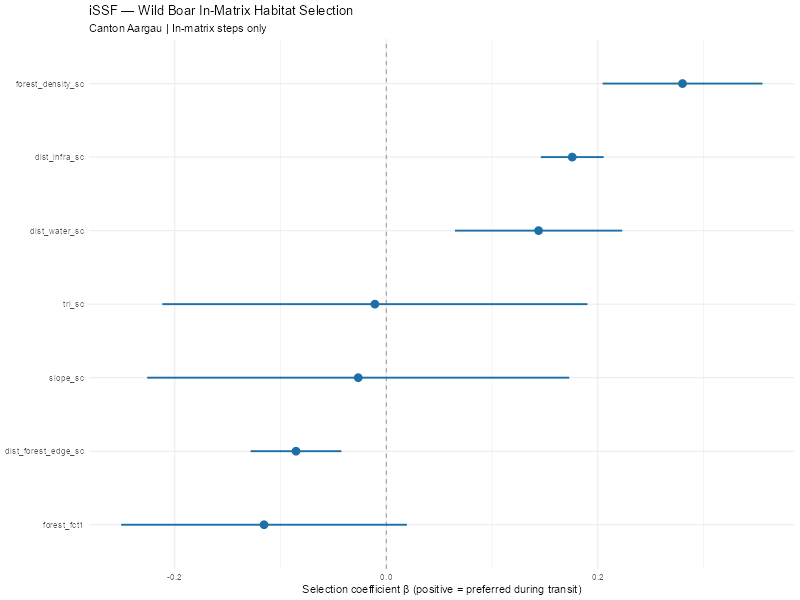


══════════════════════════════════════════════════════
  PIPELINE COMPLETE
══════════════════════════════════════════════════════

  ✓  WildBoar_InPatch_Steps.csv
  ✓  WildBoar_InMatrix_Steps.csv
  ✓  issf_coefficients.csv
  ✓  issf_coefficients.png
  ✓  suitability_resistance_maps_Aargau.png
  ✓  suitability_resistance_maps_Zurich.png
  ✓  resistance_histogram.png
  ✓  Habitat_Suitability_Wildboar_Aargau.tif
  ✓  Resistance_Keeley_Wildboar_Aargau_25m.tif
  ✓  Habitat_Suitability_Wildboar_Zurich_25m.tif
  ✓  Resistance_Keeley_Wildboar_Zurich_25m.tif


In [25]:
cat("── 8. Diagnostic plots ──\n")

# --- Plot 1: iSSF coefficient forest plot (already saved — display inline) ---
print(p_coef)

# --- Plot 2: Suitability and resistance maps side-by-side --------------------
png(file.path(OUT_DIR, "suitability_resistance_maps_Aargau.png"),
    width = 2400, height = 1100, res = 200)
par(mfrow = c(1, 2))
plot(S, main = "Habitat Suitability (0–1)\nHigh = preferred during transit",
     col = hcl.colors(50, "Greens 3"), axes = FALSE)
plot(R, main = "Resistance (Keeley C=4)\nLow = permeable",
     col = rev(hcl.colors(50, "Inferno")), axes = FALSE)
dev.off()

png(file.path(OUT_DIR, "suitability_resistance_maps_Zurich.png"),
    width = 2400, height = 1100, res = 200)
par(mfrow = c(1, 2))
plot(S_zh, main = "Habitat Suitability Zürich (0–1)",
     col = hcl.colors(50, "Greens 3"), axes = FALSE)
plot(R_zh, main = "Resistance Zürich (Keeley C=4)",
     col = rev(hcl.colors(50, "Inferno")), axes = FALSE)
dev.off()

# --- Plot 3: Resistance histogram -------------------------------------------
png(file.path(OUT_DIR, "resistance_histogram.png"),
    width = 1400, height = 800, res = 200)
r_vals <- na.omit(as.numeric(values(R)))
hist(r_vals, breaks = 60, col = "#D85A30", border = "white",
     xlab = "Resistance value", ylab = "Pixel count",
     main = "Distribution of Resistance Values — Aargau")
abline(v = R_max, col = "black", lty = 2, lwd = 1.5)
text(R_max * 0.96, par("usr")[4] * 0.88,
     "Absolute\nbarrier", adj = 1, cex = 0.7)
dev.off()

# --- Output summary ----------------------------------------------------------
cat("\n══════════════════════════════════════════════════════\n")
cat("  PIPELINE COMPLETE\n")
cat("══════════════════════════════════════════════════════\n\n")

outputs <- c(
  "WildBoar_InPatch_Steps.csv",
  "WildBoar_InMatrix_Steps.csv",
  "issf_coefficients.csv",
  "issf_coefficients.png",
  "suitability_resistance_maps_Aargau.png",
  "suitability_resistance_maps_Zurich.png",
  "resistance_histogram.png",
  "Habitat_Suitability_Wildboar_Aargau.tif",
  "Resistance_Keeley_Wildboar_Aargau_25m.tif",
  "Habitat_Suitability_Wildboar_Zurich_25m.tif",
  "Resistance_Keeley_Wildboar_Zurich_25m.tif"
)

for (f in outputs) {
  status <- if (file.exists(file.path(OUT_DIR, f))) "✓" else "✗ MISSING"
  cat(sprintf("  %s  %s\n", status, f))
}